# Unblanced LogReg Without Amount

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score, confusion_matrix, PrecisionRecallDisplay
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [2]:
DROPPED = ['Class', 'Time', 'Amount', 'V23', 'V27', 'V28', 'V26', 'V25', 'V22', 'V15', 'V13', 'V24']
TOP_N    = 12        
MIN_FEATURES = 3     

In [3]:
df = pd.read_csv('creditcard.csv')
ALL_FEATURES = [c for c in df.columns if c not in DROPPED]
print(f"Available features ({len(ALL_FEATURES)}): {ALL_FEATURES}\n")

X_all = df[ALL_FEATURES]
y     = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.3, stratify=y, random_state=42
)
X_eval, X_test, y_eval, y_test = train_test_split(
    X_test, y_test, test_size=0.5, stratify=y_test, random_state=42
)

def evaluate(features):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train[list(features)], y_train)
    y_pred = model.predict(X_eval[list(features)])
    y_probs = model.predict_proba(X_eval[list(features)])[:, 1]
    return {
        'recall':    recall_score(y_eval, y_pred),
        'precision': precision_score(y_eval, y_pred),
        'f1':        f1_score(y_eval, y_pred),
        'pr_auc':    average_precision_score(y_eval, y_probs),
    }

results = []

Available features (19): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21']



## FORWARD STEPWISE RECALL

In [4]:
print("Forward stepwise selection…\n")
selected   = []
remaining  = list(ALL_FEATURES)

while remaining:
    best_score  = -1
    best_feat   = None
    for feat in remaining:
        candidate = selected + [feat]
        if len(candidate) < MIN_FEATURES:
            # still track score but don't record yet
            m = evaluate(candidate)
            score = m["recall"]
        else:
            m = evaluate(candidate)
            score = m["recall"]
            results.append({'features': list(candidate), **m})

        if score > best_score:
            best_score = score
            best_feat  = feat
            best_metrics = m

    selected.append(best_feat)
    remaining.remove(best_feat)
    print(f"  Added '{best_feat}' → "
            f"recall={best_metrics['recall']:.4f}  "
            f"precision={best_metrics['precision']:.4f}  "
            f"f1={best_metrics['f1']:.4f}  "
            f"[{len(selected)} features]")

Forward stepwise selection…



/home/ubuntu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ubuntu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ubuntu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Added 'V14' → recall=0.5000  precision=0.6491  f1=0.5649  [1 features]
  Added 'V10' → recall=0.5811  precision=0.7414  f1=0.6515  [2 features]
  Added 'V1' → recall=0.5811  precision=0.7414  f1=0.6515  [3 features]
  Added 'V2' → recall=0.5811  precision=0.7414  f1=0.6515  [4 features]
  Added 'V5' → recall=0.5946  precision=0.7458  f1=0.6617  [5 features]
  Added 'V3' → recall=0.5946  precision=0.7458  f1=0.6617  [6 features]
  Added 'V6' → recall=0.5946  precision=0.7458  f1=0.6617  [7 features]
  Added 'V8' → recall=0.5946  precision=0.7458  f1=0.6617  [8 features]
  Added 'V21' → recall=0.6081  precision=0.7627  f1=0.6767  [9 features]
  Added 'V9' → recall=0.6081  precision=0.7500  f1=0.6716  [10 features]
  Added 'V11' → recall=0.6081  precision=0.7500  f1=0.6716  [11 features]
  Added 'V16' → recall=0.6081  precision=0.8036  f1=0.6923  [12 features]
  Added 'V7' → recall=0.6216  precision=0.8070  f1=0.7023  [13 features]
  Added 'V17' → recall=0.6216  precision=0.8070  f1=0.7

In [5]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("recall", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY RECALl")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_fs_unbalanced_recall.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY RECALl
══════════════════════════════════════════════════════

Rank 1  (15 features)
  Recall:    0.6216
  Precision: 0.8070
  F1:        0.7023
  PR AUC:    0.6524
  Features:  ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7', 'V17', 'V18']

Rank 2  (14 features)
  Recall:    0.6216
  Precision: 0.8070
  F1:        0.7023
  PR AUC:    0.6549
  Features:  ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7', 'V19']

Rank 3  (14 features)
  Recall:    0.6216
  Precision: 0.8070
  F1:        0.7023
  PR AUC:    0.6532
  Features:  ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7', 'V17']

Rank 4  (13 features)
  Recall:    0.6216
  Precision: 0.8070
  F1:        0.7023
  PR AUC:    0.6544
  Features:  ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7']

Rank 5  (15 features)
  Recall

## FORWARD STEPWISE PR AUC

In [6]:
print("Forward stepwise selection…\n")
selected   = []
remaining  = list(ALL_FEATURES)

while remaining:
    best_score  = -1
    best_feat   = None
    for feat in remaining:
        candidate = selected + [feat]
        if len(candidate) < MIN_FEATURES:
            # still track score but don't record yet
            m = evaluate(candidate)
            score = m["pr_auc"]
        else:
            m = evaluate(candidate)
            score = m["pr_auc"]
            results.append({'features': list(candidate), **m})

        if score > best_score:
            best_score = score
            best_feat  = feat
            best_metrics = m

    selected.append(best_feat)
    remaining.remove(best_feat)
    print(f"  Added '{best_feat}' → "
            f"recall={best_metrics['recall']:.4f}  "
            f"precision={best_metrics['precision']:.4f}  "
            f"f1={best_metrics['f1']:.4f}  "
            f"[{len(selected)} features]")

Forward stepwise selection…



/home/ubuntu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ubuntu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ubuntu/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Added 'V14' → recall=0.5000  precision=0.6491  f1=0.5649  [1 features]
  Added 'V10' → recall=0.5811  precision=0.7414  f1=0.6515  [2 features]
  Added 'V8' → recall=0.5811  precision=0.7414  f1=0.6515  [3 features]
  Added 'V16' → recall=0.5811  precision=0.7963  f1=0.6719  [4 features]
  Added 'V4' → recall=0.5811  precision=0.7963  f1=0.6719  [5 features]
  Added 'V21' → recall=0.5946  precision=0.8000  f1=0.6822  [6 features]
  Added 'V3' → recall=0.5946  precision=0.8000  f1=0.6822  [7 features]
  Added 'V1' → recall=0.5811  precision=0.7963  f1=0.6719  [8 features]
  Added 'V20' → recall=0.5811  precision=0.7963  f1=0.6719  [9 features]
  Added 'V19' → recall=0.5811  precision=0.7963  f1=0.6719  [10 features]
  Added 'V18' → recall=0.5811  precision=0.7963  f1=0.6719  [11 features]
  Added 'V11' → recall=0.5811  precision=0.7963  f1=0.6719  [12 features]
  Added 'V12' → recall=0.5811  precision=0.7963  f1=0.6719  [13 features]
  Added 'V9' → recall=0.5811  precision=0.7963  f1=

In [7]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY PR AUC")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_fs_unbalanced_pr_auc.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY PR AUC
══════════════════════════════════════════════════════

Rank 1  (9 features)
  Recall:    0.5811
  Precision: 0.7963
  F1:        0.6719
  PR AUC:    0.6697
  Features:  ['V14', 'V10', 'V8', 'V16', 'V4', 'V21', 'V3', 'V1', 'V20']

Rank 2  (10 features)
  Recall:    0.5811
  Precision: 0.7963
  F1:        0.6719
  PR AUC:    0.6693
  Features:  ['V14', 'V10', 'V8', 'V16', 'V4', 'V21', 'V3', 'V1', 'V20', 'V19']

Rank 3  (10 features)
  Recall:    0.5811
  Precision: 0.7963
  F1:        0.6719
  PR AUC:    0.6690
  Features:  ['V14', 'V10', 'V8', 'V16', 'V4', 'V21', 'V3', 'V1', 'V20', 'V18']

Rank 4  (9 features)
  Recall:    0.5811
  Precision: 0.7963
  F1:        0.6719
  PR AUC:    0.6689
  Features:  ['V14', 'V10', 'V8', 'V16', 'V4', 'V21', 'V3', 'V1', 'V18']

Rank 5  (11 features)
  Recall:    0.5811
  Precision: 0.7963
  F1:        0.6719
  PR AUC:    0.6688
  Features:  ['V14', 'V10', 'V8', 'V16',

## TOP N

In [8]:
print("Ranking features by logistic regression importance…")
base_model = LogisticRegression(max_iter=1000)
base_model.fit(X_train, y_train)
importances = pd.Series(np.abs(base_model.coef_[0]), index=ALL_FEATURES)
top_features = importances.nlargest(TOP_N).index.tolist()
print(f"Top {TOP_N} features: {top_features}\n")

total = sum(1 for k in range(MIN_FEATURES, len(top_features)+1)
            for _ in combinations(top_features, k))
print(f"Exhaustive search over top {TOP_N}: {total:,} combinations…\n")
done = 0
for k in range(MIN_FEATURES, len(top_features) + 1):
    for combo in combinations(top_features, k):
        metrics = evaluate(combo)
        results.append({'features': list(combo), **metrics})
        done += 1
        if done % 200 == 0:
            print(f"  {done:,} / {total:,} done…")

Ranking features by logistic regression importance…
Top 12 features: ['V14', 'V4', 'V10', 'V16', 'V9', 'V8', 'V21', 'V12', 'V7', 'V20', 'V11', 'V1']

Exhaustive search over top 12: 4,017 combinations…



  200 / 4,017 done…
  400 / 4,017 done…


KeyboardInterrupt: 

In [ ]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("recall", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY RECALl")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_top_n_unbalanced_recall.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY RECALl
══════════════════════════════════════════════════════

Rank 1  (15 features)
  Recall:    0.6216
  Precision: 0.8070
  F1:        0.7023
  PR AUC:    0.6548
  Features:  ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7', 'V17', 'V20']

Rank 2  (17 features)
  Recall:    0.6216
  Precision: 0.8070
  F1:        0.7023
  PR AUC:    0.6548
  Features:  ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7', 'V17', 'V18', 'V19', 'V20']

Rank 3  (13 features)
  Recall:    0.6216
  Precision: 0.8070
  F1:        0.7023
  PR AUC:    0.6544
  Features:  ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7']

Rank 4  (13 features)
  Recall:    0.6216
  Precision: 0.8070
  F1:        0.7023
  PR AUC:    0.6549
  Features:  ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V20']

Rank 5  (14 fea

In [ ]:
results_df = pd.DataFrame(results)
results_df['n_features'] = results_df['features'].apply(len)
results_df = results_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\n══════════════════════════════════════════════════════")
print(f"TOP 10 COMBINATIONS BY PR AUC")
print("══════════════════════════════════════════════════════")
for i, row in results_df.head(10).iterrows():
    print(f"\nRank {i+1}  ({row['n_features']} features)")
    print(f"  Recall:    {row['recall']:.4f}")
    print(f"  Precision: {row['precision']:.4f}")
    print(f"  F1:        {row['f1']:.4f}")
    print(f"  PR AUC:    {row['pr_auc']:.4f}")
    print(f"  Features:  {row['features']}")

out_path = 'csv_new/logreg_top_n_unbalanced_pr_auc.csv'
results_df['features'] = results_df['features'].apply(str)
results_df.to_csv(out_path, index=False)
print(f"\nAll results saved to '{out_path}'")


══════════════════════════════════════════════════════
TOP 10 COMBINATIONS BY PR AUC
══════════════════════════════════════════════════════

Rank 1  (9 features)
  Recall:    0.5811
  Precision: 0.7963
  F1:        0.6719
  PR AUC:    0.6697
  Features:  ['V14', 'V10', 'V8', 'V16', 'V4', 'V21', 'V3', 'V1', 'V20']

Rank 2  (10 features)
  Recall:    0.5811
  Precision: 0.7963
  F1:        0.6719
  PR AUC:    0.6693
  Features:  ['V14', 'V10', 'V8', 'V16', 'V4', 'V21', 'V3', 'V1', 'V20', 'V19']

Rank 3  (10 features)
  Recall:    0.5811
  Precision: 0.7963
  F1:        0.6719
  PR AUC:    0.6690
  Features:  ['V14', 'V10', 'V8', 'V16', 'V4', 'V21', 'V3', 'V1', 'V20', 'V18']

Rank 4  (9 features)
  Recall:    0.5811
  Precision: 0.7963
  F1:        0.6719
  PR AUC:    0.6689
  Features:  ['V14', 'V10', 'V8', 'V16', 'V4', 'V21', 'V3', 'V1', 'V18']

Rank 5  (11 features)
  Recall:    0.5811
  Precision: 0.7963
  F1:        0.6719
  PR AUC:    0.6688
  Features:  ['V14', 'V10', 'V8', 'V16',

# Compare the results

In [9]:
forward_stepwise = pd.read_csv('csv_new/logreg_fs_unbalanced_recall.csv')
forward_stepwise_pr_auc = pd.read_csv('csv_new/logreg_fs_unbalanced_pr_auc.csv')
top_n = pd.read_csv('csv_new/logreg_top_n_unbalanced_recall.csv')

fs_dataframes = {
    'recall': forward_stepwise,
    'pr_auc': forward_stepwise_pr_auc
}

best_of = ['recall', 'pr_auc']

for metric in best_of:
    fs = fs_dataframes[metric].sort_values(metric, ascending=False)
    top = top_n.sort_values(metric, ascending=False)

    print("\n══════════════════════════════════════════════════════")
    print(f'BEST OF {metric.upper()}  — SIDE BY SIDE')
    print("══════════════════════════════════════════════════════")
    metrics = ['recall', 'precision', 'f1', 'pr_auc']
    summary = pd.DataFrame({
        'Metric': metrics,
        f'Forward_Stepwise ({metric.upper()})': [fs[m].iloc[0] for m in metrics],
        f'Top_N ({metric.upper()})': [top[m].iloc[0] for m in metrics],
    })
    summary['Difference'] = summary[f'Top_N ({metric.upper()})'] - summary[f'Forward_Stepwise ({metric.upper()})']
    summary['Winner'] = summary['Difference'].apply(lambda x: f'Top_N ({metric.upper()})' if x > 0 else (f'Forward_Stepwise ({metric.upper()})' if x < 0 else 'Tie'))
    summary["Winner_Features"] = summary["Winner"].apply(
    lambda x: fs['features'].iloc[0] if "Forward_Stepwise" in x
    else (top['features'].iloc[0] if "Top_N" in x else top['features'].iloc[0] + "; " + fs['features'].iloc[0]))
    print(summary.to_string(index=False))
    print(summary.to_string(index=False))


══════════════════════════════════════════════════════
BEST OF RECALL  — SIDE BY SIDE
══════════════════════════════════════════════════════
   Metric  Forward_Stepwise (RECALL)  Top_N (RECALL)  Difference         Winner                                                                                                                                                                                             Winner_Features
   recall                   0.621622        0.621622    0.000000            Tie ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7', 'V17', 'V18', 'V20']; ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7', 'V17', 'V18']
precision                   0.807018        0.807018    0.000000            Tie ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7', 'V17', 'V18', 'V20']; ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7', 'V17', 'V18']
      

# Generate HeatMap


ERGEBNISSE für Test: Unbalanced Forward Stepwise LogReg (Recall)
🔹 Recall:    0.6216  (Findet 62.2% der Betrugsfälle)
🔹 Precision: 0.9200  (92.0% der Alarme sind echt)
🔹 F1-Score:  0.7419
🔹 PR-AUC:    0.7492
🔹 Features:  ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7', 'V17', 'V18'], 15
---------------------------------------------



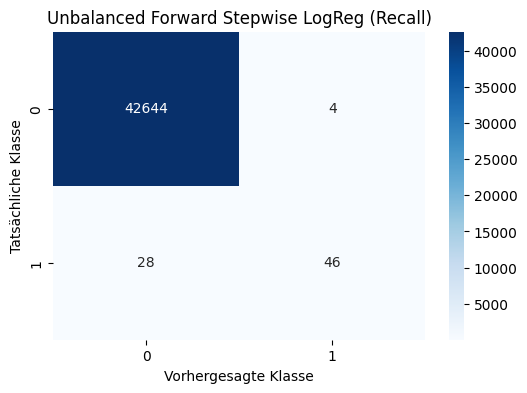

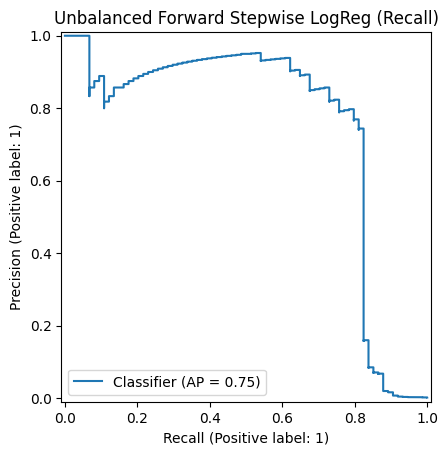

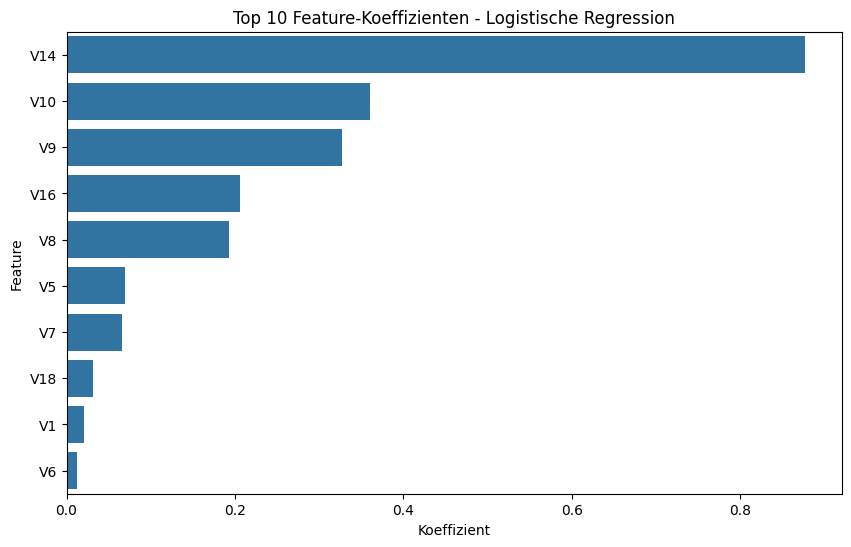


ERGEBNISSE für Test: Unbalanced Top N LogReg (Recall)
🔹 Recall:    0.6216  (Findet 62.2% der Betrugsfälle)
🔹 Precision: 0.9200  (92.0% der Alarme sind echt)
🔹 F1-Score:  0.7419
🔹 PR-AUC:    0.7498
🔹 Features:  ['V14', 'V10', 'V1', 'V2', 'V5', 'V3', 'V6', 'V8', 'V21', 'V9', 'V11', 'V16', 'V7', 'V17', 'V18', 'V20'], 16
---------------------------------------------



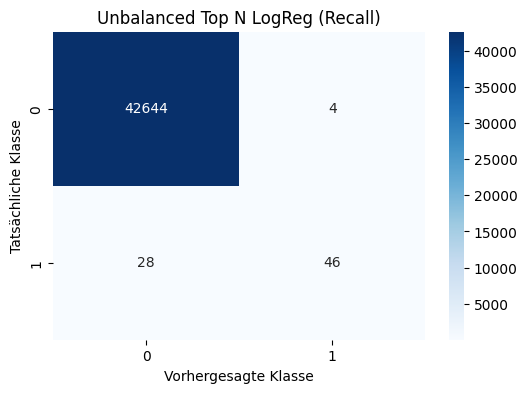

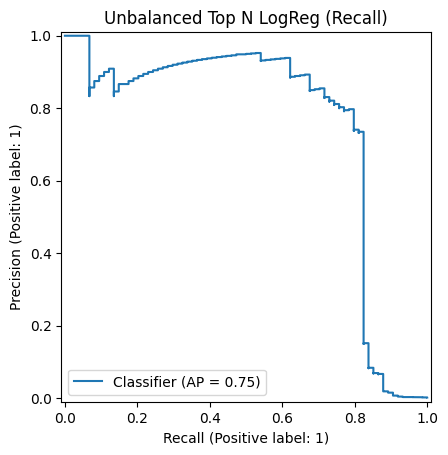

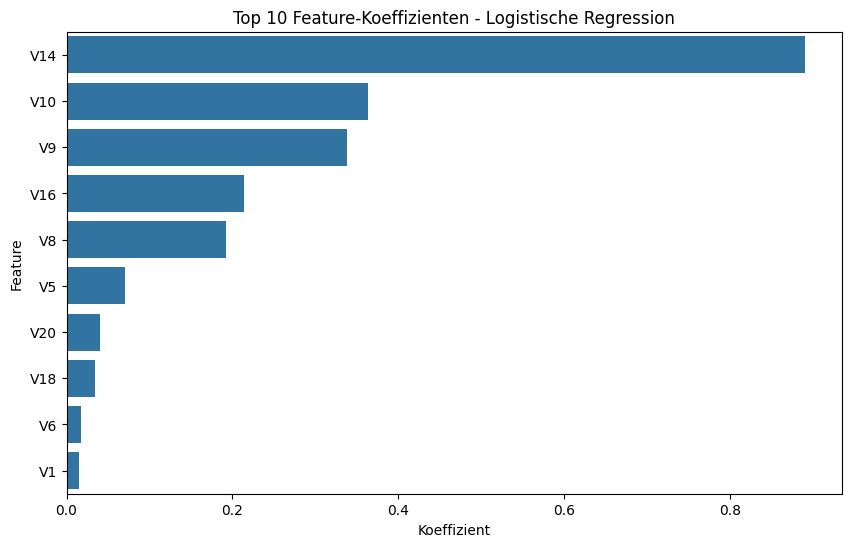


ERGEBNISSE für Test: Unbalanced Forward Stepwise LogReg (PR AUC)
🔹 Recall:    0.6081  (Findet 60.8% der Betrugsfälle)
🔹 Precision: 0.9184  (91.8% der Alarme sind echt)
🔹 F1-Score:  0.7317
🔹 PR-AUC:    0.7490
🔹 Features:  ['V14', 'V10', 'V8', 'V16', 'V4', 'V21', 'V3', 'V1', 'V20'], 9
---------------------------------------------



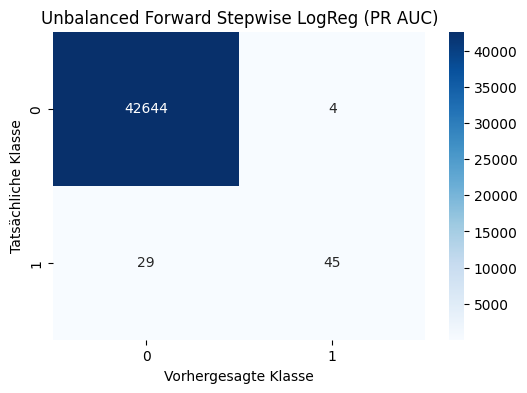

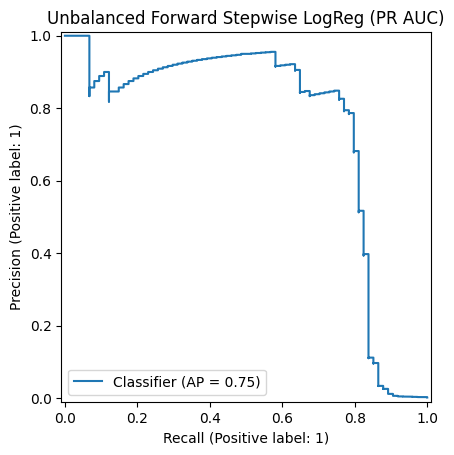

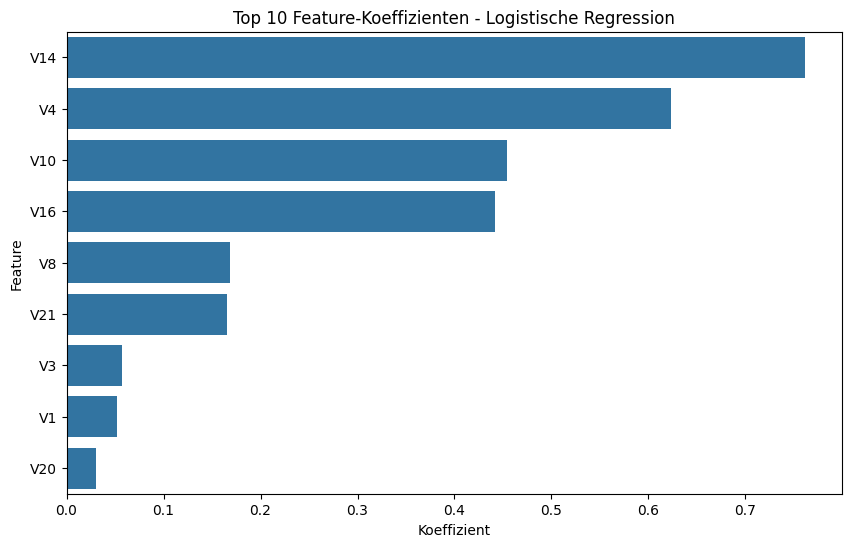


ERGEBNISSE für Test: Unbalanced Top N LogReg (PR AUC)
🔹 Recall:    0.6081  (Findet 60.8% der Betrugsfälle)
🔹 Precision: 0.9184  (91.8% der Alarme sind echt)
🔹 F1-Score:  0.7317
🔹 PR-AUC:    0.7490
🔹 Features:  ['V14', 'V10', 'V8', 'V16', 'V4', 'V21', 'V3', 'V1', 'V20'], 9
---------------------------------------------



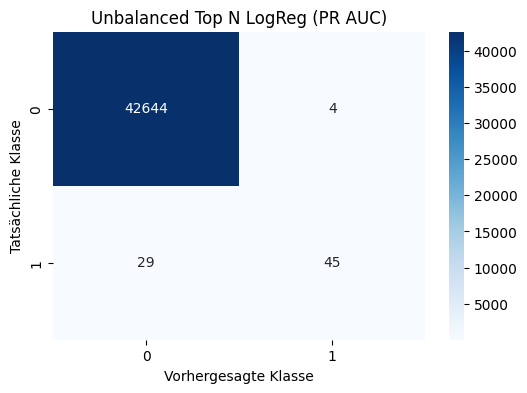

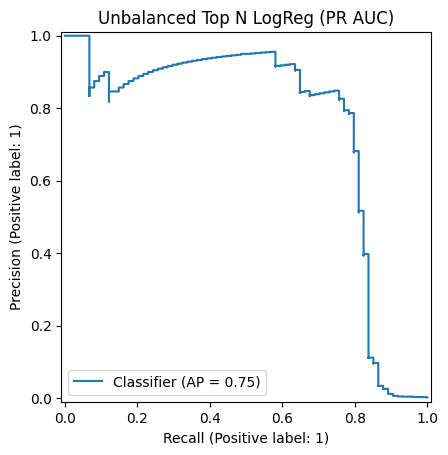

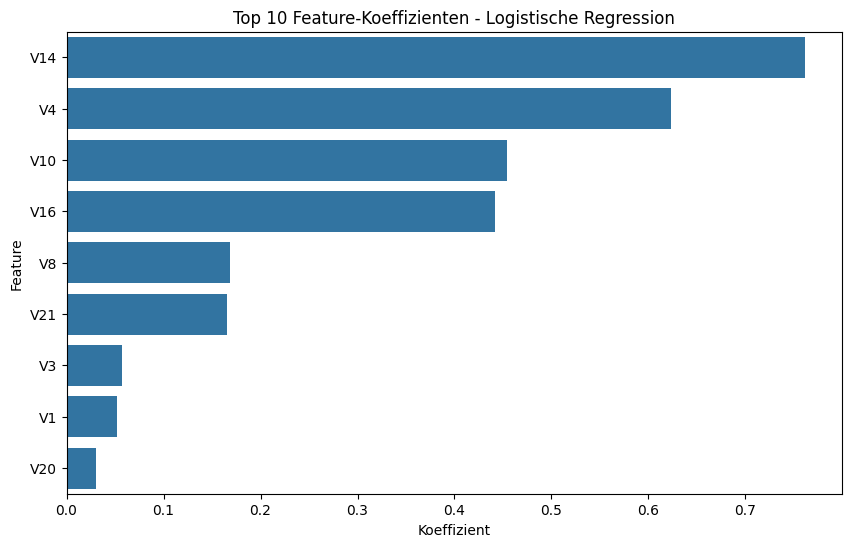

In [11]:
def evaluate(features, title):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train[list(features)], y_train)
    y_pred = model.predict(X_test[list(features)])
    y_probs = model.predict_proba(X_test[list(features)])[:, 1]

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    pr_auc = average_precision_score(y_test, y_probs)

    # 1. SCHÖNE KONSOLENAUSGABE
    print(f"\n" + "="*45)
    print(f"ERGEBNISSE für Test: {title}")
    print(f"="*45)
    print(f"🔹 Recall:    {recall:.4f}  (Findet {recall*100:.1f}% der Betrugsfälle)")
    print(f"🔹 Precision: {precision:.4f}  ({precision*100:.1f}% der Alarme sind echt)")
    print(f"🔹 F1-Score:  {f1:.4f}")
    print(f"🔹 PR-AUC:    {pr_auc:.4f}")
    print(f"🔹 Features:  {features}, {len(features)}")
    print(f"-"*45 + "\n")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('Tatsächliche Klasse')
    plt.xlabel('Vorhergesagte Klasse')
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_test, y_probs)
    plt.title(title)
    plt.show()

    # Angenommen, dein trainiertes Modell heißt 'log_reg' und deine Features 'X_train'
    koeffizienten = abs(model.coef_[0])
    feature_names = model.feature_names_in_

    # Ein DataFrame daraus machen und nach Größe sortieren
    coef_df = pd.DataFrame({'Feature': feature_names, 'Koeffizient': koeffizienten})
    coef_df = coef_df.sort_values(by='Koeffizient', ascending=False)

    # Die Top 10 wichtigsten Features plotten (positiv und negativ)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Koeffizient', y='Feature', data=pd.concat([coef_df.head(5), coef_df.tail(5)]))
    plt.title('Top 10 Feature-Koeffizienten - Logistische Regression')
    plt.show()

forward_stepwise_recall = forward_stepwise.sort_values("recall", ascending=False)
top_n_recall = top_n.sort_values("recall", ascending=False)

evaluate(ast.literal_eval(forward_stepwise_recall['features'].iloc[0]), "Unbalanced Forward Stepwise LogReg (Recall)")
evaluate(ast.literal_eval(top_n_recall['features'].iloc[0]), "Unbalanced Top N LogReg (Recall)")

forward_stepwise_pr_auc = forward_stepwise_pr_auc.sort_values("pr_auc", ascending=False)
top_n_pr_auc = top_n.sort_values("pr_auc", ascending=False)

evaluate(ast.literal_eval(forward_stepwise_pr_auc['features'].iloc[0]), "Unbalanced Forward Stepwise LogReg (PR AUC)")
evaluate(ast.literal_eval(top_n_pr_auc['features'].iloc[0]), "Unbalanced Top N LogReg (PR AUC)")



In [ ]:
# Angenommen, dein trainiertes Modell heißt 'log_reg' und deine Features 'X_train'
koeffizienten = log_reg.coef_[0]
feature_names = X_train.columns

# Ein DataFrame daraus machen und nach Größe sortieren
coef_df = pd.DataFrame({'Feature': feature_names, 'Koeffizient': koeffizienten})
coef_df = coef_df.sort_values(by='Koeffizient', ascending=False)

# Die Top 10 wichtigsten Features plotten (positiv und negativ)
plt.figure(figsize=(10, 6))
sns.barplot(x='Koeffizient', y='Feature', data=pd.concat([coef_df.head(5), coef_df.tail(5)]))
plt.title('Logistische Regression: Top 10 Feature-Koeffizienten')
plt.show()